In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv("../data/olist_customers_dataset.csv")
orders = pd.read_csv("../data/olist_orders_dataset.csv")
items = pd.read_csv("../data/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
sellers = pd.read_csv("../data/olist_sellers_dataset.csv")

## Univariate Analysis

Order Value Distribution

In [3]:
order_value = (
    payments.groupby('order_id', as_index=False)['payment_value']
    .sum()
    .rename(columns={'payment_value': 'order_value'})
)

In [4]:
order_value['order_value'].describe()

count    99440.000000
mean       160.990267
std        221.951257
min          0.000000
25%         62.010000
50%        105.290000
75%        176.970000
max      13664.080000
Name: order_value, dtype: float64

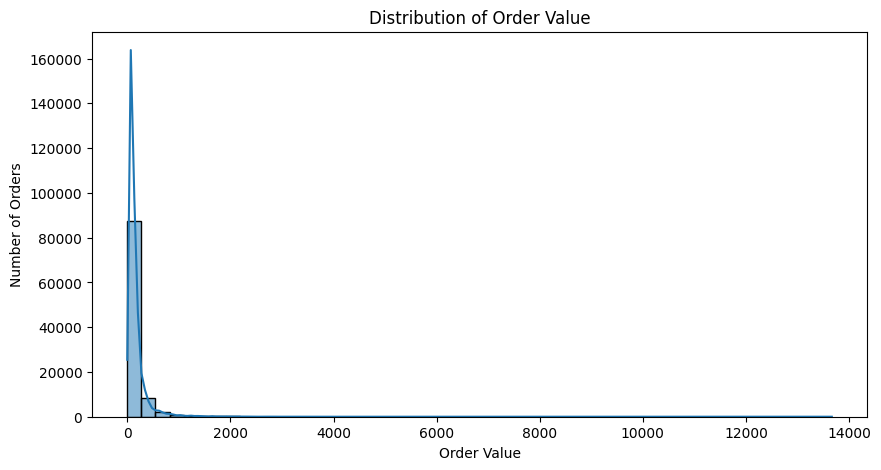

In [5]:
plt.figure(figsize=(10, 5))

sns.histplot(
    order_value['order_value'],
    bins=50,
    kde=True
)

plt.title('Distribution of Order Value')
plt.xlabel('Order Value')
plt.ylabel('Number of Orders')
plt.show()

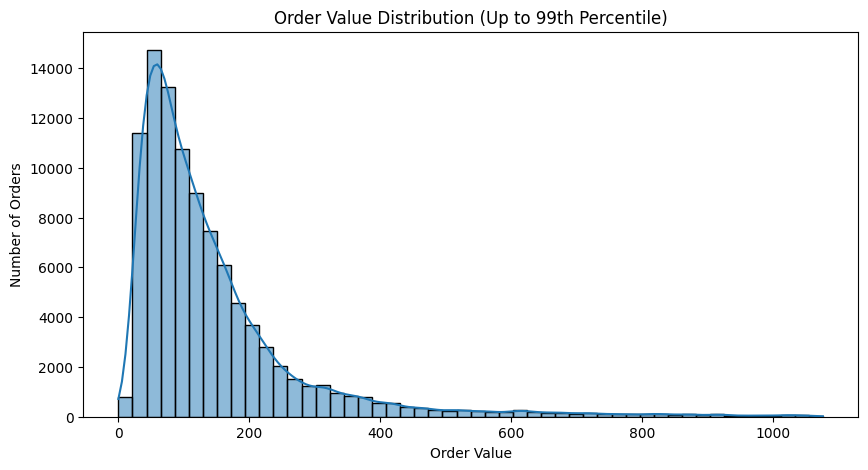

In [6]:
q99 = order_value['order_value'].quantile(0.99)

plt.figure(figsize=(10, 5))

sns.histplot(
    order_value.loc[order_value['order_value'] <= q99, 'order_value'],
    bins=50,
    kde=True
)

plt.title('Order Value Distribution (Up to 99th Percentile)')
plt.xlabel('Order Value')
plt.ylabel('Number of Orders')
plt.show()

Delivery Time Distribution

In [7]:
orders['delivery_days'] = (pd.to_datetime(orders['order_delivered_customer_date']) - pd.to_datetime(orders['order_purchase_timestamp'])).dt.days

In [12]:
delivered_orders = orders[(orders['order_status'] == 'delivered') & orders['delivery_days'].notnull()].copy()

In [13]:
delivered_orders['delivery_days'].describe()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

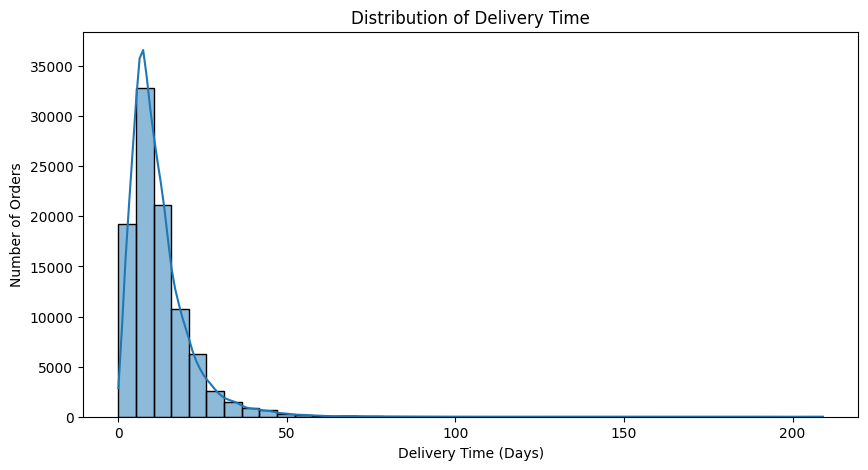

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(
    delivered_orders['delivery_days'],
    bins=40,
    kde=True
)

plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Number of Orders')
plt.show()

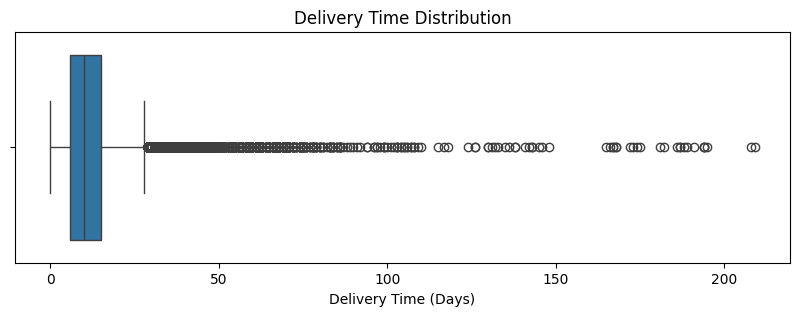

In [16]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=delivered_orders['delivery_days']
)

plt.title('Delivery Time Distribution')
plt.xlabel('Delivery Time (Days)')
plt.show()

Review Score Distribution

In [19]:
review_pct = (
    reviews['review_score']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

review_pct

review_score
1    11.513344
2     3.175643
3     8.242965
4    19.291704
5    57.776344
Name: proportion, dtype: float64

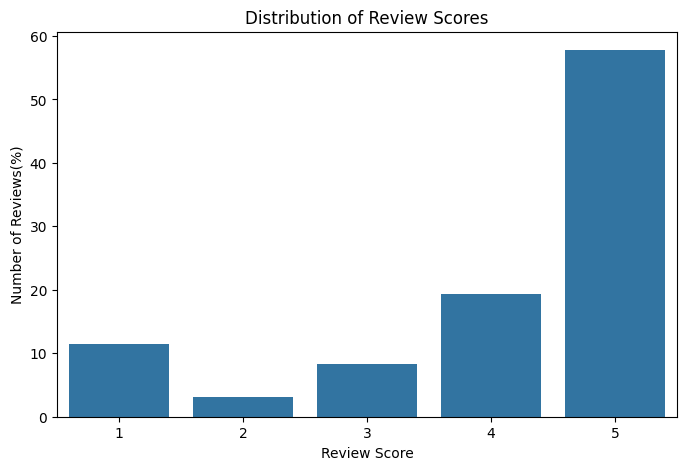

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=review_pct.index,
    y=review_pct.values
)

plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews(%)')
plt.show()

Payment Value Distribution

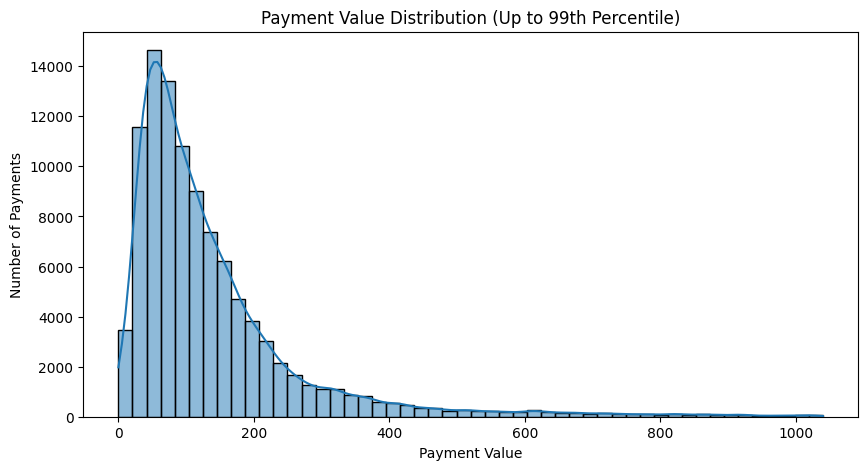

In [23]:
q99 = payments['payment_value'].quantile(0.99)

plt.figure(figsize=(10, 5))

sns.histplot(
    payments.loc[
        payments['payment_value'] <= q99,
        'payment_value'
    ],
    bins=50,
    kde=True
)

plt.title('Payment Value Distribution (Up to 99th Percentile)')
plt.xlabel('Payment Value')
plt.ylabel('Number of Payments')
plt.show()

## Outlier Analysis

In [24]:
def outlier_summary(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    return {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': len(outliers),
        'outlier_percentage': len(outliers) / len(df) * 100
    }

Order Value

In [25]:
outlier_summary(order_value, 'order_value')

{'Q1': np.float64(62.01),
 'Q3': np.float64(176.97),
 'IQR': np.float64(114.96000000000001),
 'lower_bound': np.float64(-110.43),
 'upper_bound': np.float64(349.40999999999997),
 'outlier_count': 7866,
 'outlier_percentage': 7.910297666934834}

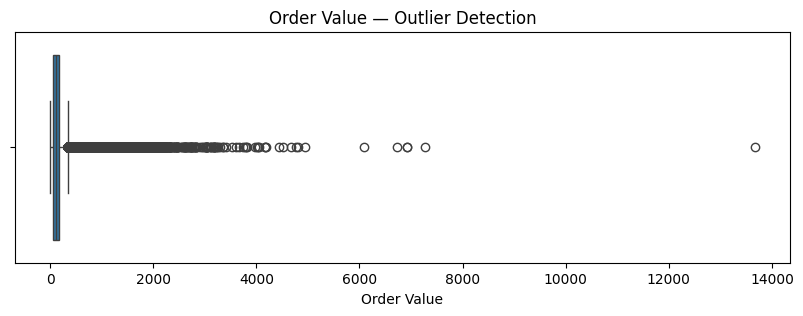

In [26]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=order_value['order_value']
)

plt.title('Order Value — Outlier Detection')
plt.xlabel('Order Value')
plt.show()

Delivery Time

In [ ]:
outlier_summary(delivered_orders, 'delivery_days')

{'Q1': np.float64(6.0),
 'Q3': np.float64(15.0),
 'IQR': np.float64(9.0),
 'lower_bound': np.float64(-7.5),
 'upper_bound': np.float64(28.5),
 'outlier_count': 5022,
 'outlier_percentage': 5.205763449777133}

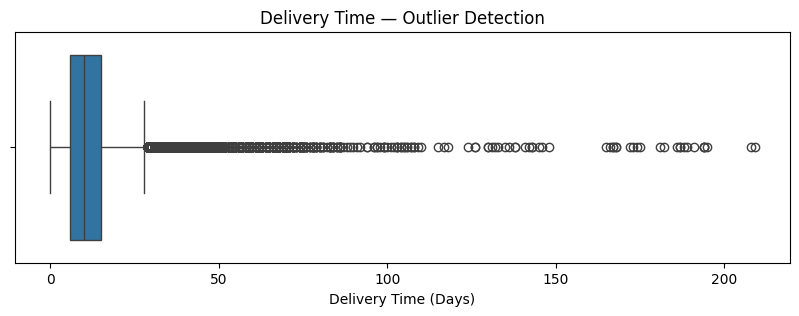

In [28]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=delivered_orders['delivery_days']
)

plt.title('Delivery Time — Outlier Detection')
plt.xlabel('Delivery Time (Days)')
plt.show()

In [ ]:
#Check outlier values
upper = delivered_orders['delivery_days'].quantile(0.99)

delivered_orders[
    delivered_orders['delivery_days'] > upper
][[
    'order_id',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'delivery_days'
]].sort_values(
    'delivery_days',
    ascending=False
).head(10)

,order_id,order_purchase_timestamp,order_delivered_customer_date,delivery_days
19590,ca07593549f1816d26a572e06dc1eab6,2017-02-21 23:31:27,2017-09-19 14:36:39,209.0
55619,1b3190b2dfa9d789e1f14c05b647a14a,2018-02-23 14:57:35,2018-09-19 23:24:07,208.0
61610,440d0d17af552815d15a9e41abe49359,2017-03-07 23:59:51,2017-09-19 15:12:50,195.0
70307,2fb597c2f772eca01b1f5c561bf6cc7b,2017-03-08 18:09:02,2017-09-19 14:33:17,194.0
38509,0f4519c5f1c541ddec9f21b3bddd533a,2017-03-09 13:26:57,2017-09-19 14:38:21,194.0
89130,285ab9426d6982034523a855f55a885e,2017-03-08 22:47:40,2017-09-19 14:00:04,194.0
11399,47b40429ed8cce3aee9199792275433f,2018-01-03 09:44:01,2018-07-13 20:51:31,191.0
81401,2fe324febf907e3ea3f2aa9650869fa5,2017-03-13 20:17:10,2017-09-19 17:00:07,189.0
54480,2d7561026d542c8dbd8f0daeadf67a43,2017-03-15 11:24:27,2017-09-19 14:38:18,188.0
68769,c27815f7e3dd0b926b58552628481575,2017-03-15 23:23:17,2017-09-19 17:14:25,187.0


Payment Value

In [30]:
outlier_summary(payments, 'payment_value')

{'Q1': np.float64(56.79),
 'Q3': np.float64(171.8375),
 'IQR': np.float64(115.04750000000001),
 'lower_bound': np.float64(-115.78125000000003),
 'upper_bound': np.float64(344.40875000000005),
 'outlier_count': 7981,
 'outlier_percentage': 7.682459619197966}

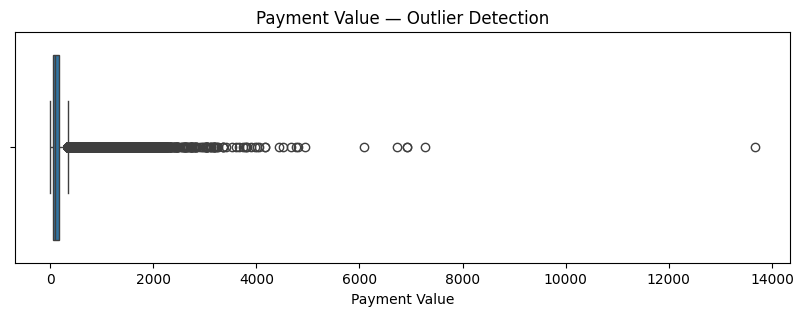

In [31]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=payments['payment_value']
)

plt.title('Payment Value — Outlier Detection')
plt.xlabel('Payment Value')
plt.show()

## Bivariate Analysis

In [32]:
delivery_review = delivered_orders[
    ['order_id', 'delivery_days']
].merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

In [33]:
delivery_review.head()

,order_id,delivery_days,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,8.0,4
1,53cdb2fc8bc7dce0b6741e2150273451,13.0,4
2,47770eb9100c2d0c44946d9cf07ec65d,9.0,5
3,949d5b44dbf5de918fe9c16f97b45f8a,13.0,5
4,ad21c59c0840e6cb83a9ceb5573f8159,2.0,5


In [36]:
bins = [-1, 5, 10, 15, 20, np.inf]
labels = ['0-5 days', '6-10 days', '11-15 days', '16-20 days', '>20 days']

delivery_review['delivery_timespan'] = pd.cut(
    delivery_review['delivery_days'],
    bins=bins,
    labels=labels
)

rating_by_delivery = (
    delivery_review
    .groupby('delivery_timespan', observed=True)['review_score']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

rating_by_delivery

,delivery_timespan,mean,median,count
0,0-5 days,4.430808,5.0,19229
1,6-10 days,4.347884,5.0,32850
2,11-15 days,4.245394,5.0,21166
3,16-20 days,4.091147,5.0,10719
4,>20 days,3.121640,3.0,12389


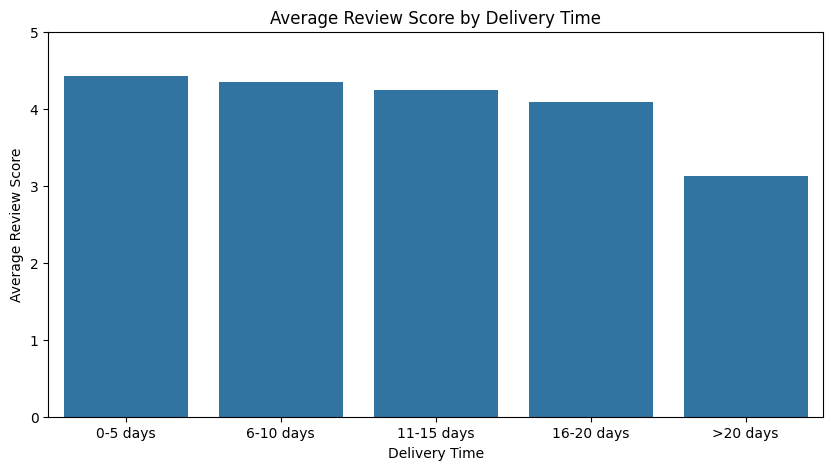

In [37]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=rating_by_delivery,
    x='delivery_timespan',
    y='mean'
)

plt.title('Average Review Score by Delivery Time')
plt.xlabel('Delivery Time')
plt.ylabel('Average Review Score')
plt.ylim(0, 5)

plt.show()

Late vs On-time Rating

In [38]:
delivered_orders['delivery_performance'] = np.where(
    delivered_orders['order_delivered_customer_date'] > delivered_orders['order_estimated_delivery_date'],
    'Late',
    'On-time'
)

In [39]:
late_review = delivered_orders[
    ['order_id', 'delivery_performance']
].merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

In [40]:
late_review.groupby('delivery_performance')['review_score'].agg(['mean', 'median', 'count'])

,mean,median,count
delivery_performance,,,
Late,2.566494,2.0,7700
On-time,4.293718,5.0,88653


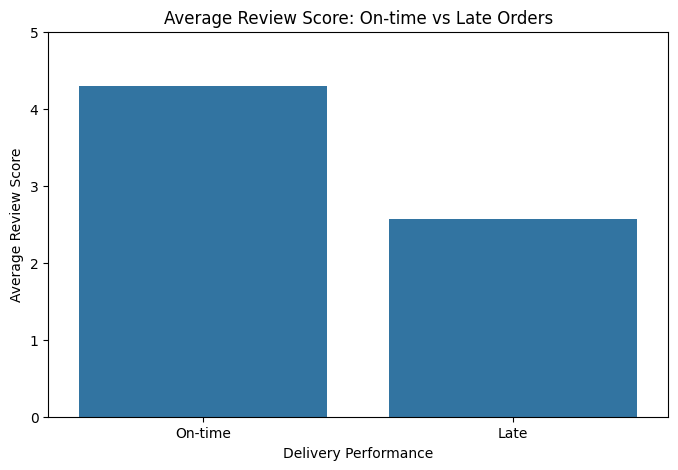

In [41]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=late_review,
    x='delivery_performance',
    y='review_score',
    errorbar=None
)

plt.title('Average Review Score: On-time vs Late Orders')
plt.xlabel('Delivery Performance')
plt.ylabel('Average Review Score')
plt.ylim(0, 5)

plt.show()

Payment Value by Payment Method

In [43]:
payment_summary = (payments.groupby('payment_type')['payment_value'].agg(['mean', 'median', 'count']).reset_index())

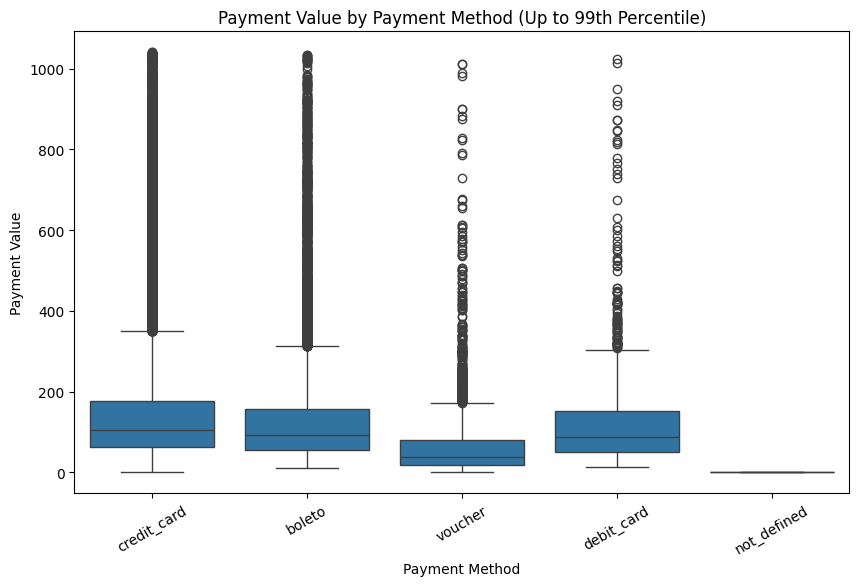

In [45]:
q99 = payments['payment_value'].quantile(0.99)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=payments[payments['payment_value'] <= q99],
    x='payment_type',
    y='payment_value'
)

plt.title('Payment Value by Payment Method (Up to 99th Percentile)')
plt.xlabel('Payment Method')
plt.ylabel('Payment Value')
plt.xticks(rotation=30)

plt.show()

Freight Value vs Delivery Time

In [47]:
item_delivery = items.merge(delivered_orders[['order_id', 'delivery_days']],on='order_id',how='inner')

In [48]:
freight_by_order = (item_delivery.groupby('order_id').agg(
        freight_value=('freight_value', 'sum'),
        delivery_days=('delivery_days', 'first')
    ).reset_index())

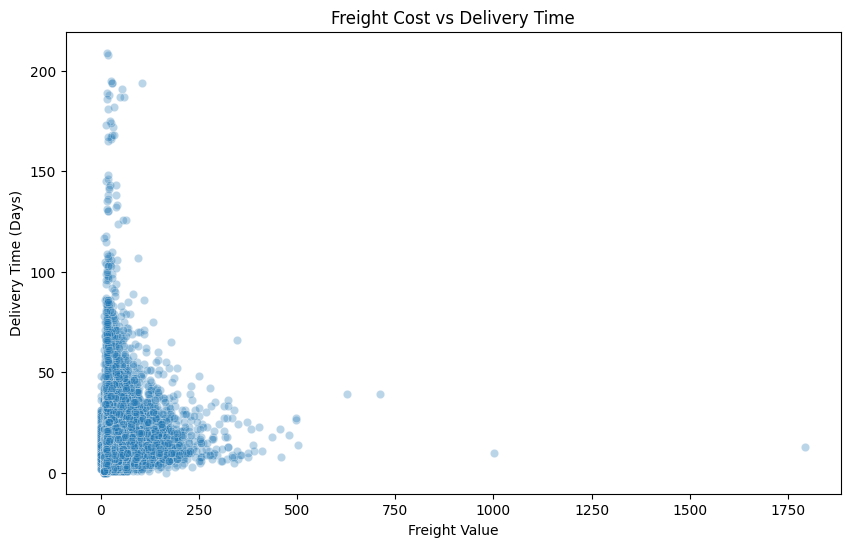

In [49]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=freight_by_order,
    x='freight_value',
    y='delivery_days',
    alpha=0.3
)

plt.title('Freight Cost vs Delivery Time')
plt.xlabel('Freight Value')
plt.ylabel('Delivery Time (Days)')

plt.show()

In [50]:
freight_by_order[
    ['freight_value', 'delivery_days']
].corr()

,freight_value,delivery_days
freight_value,1.00000,0.16711
delivery_days,0.16711,1.00000


## HEATMAP

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation_heatmap(df, table_name):
    numeric_df = df.select_dtypes(include='number')

    if numeric_df.shape[1] < 2:
        print(f"{table_name}: Not enough numeric variables to create a correlation heatmap.")
        return

    corr = numeric_df.corr()

    plt.figure(figsize=(10, 7))

    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        linewidths=0.5
    )

    plt.title(f'Correlation Heatmap — {table_name}')
    plt.tight_layout()
    plt.show()

Order Items

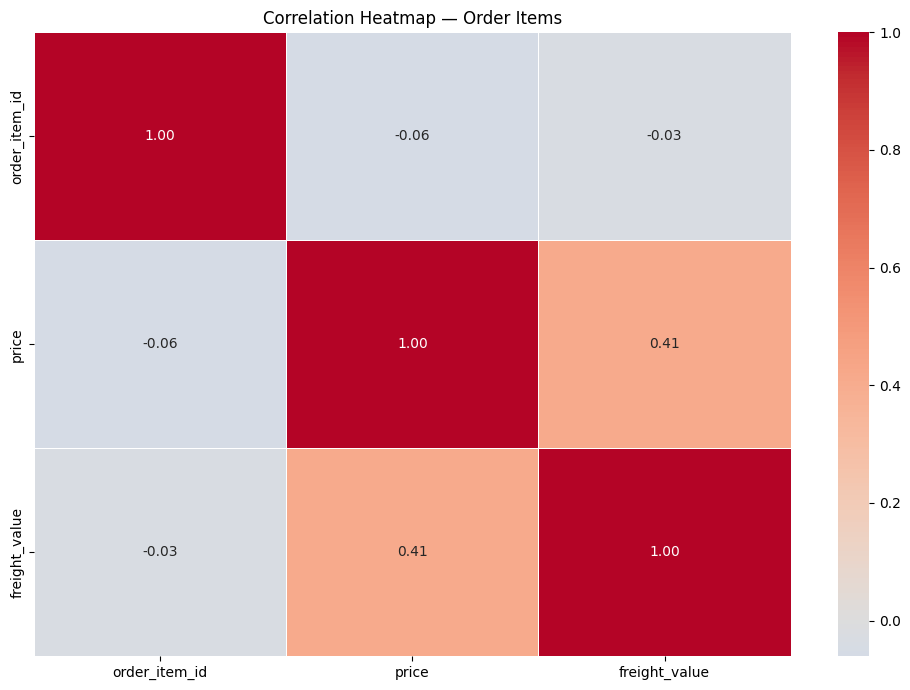

In [52]:
plot_correlation_heatmap(items, 'Order Items')

Products

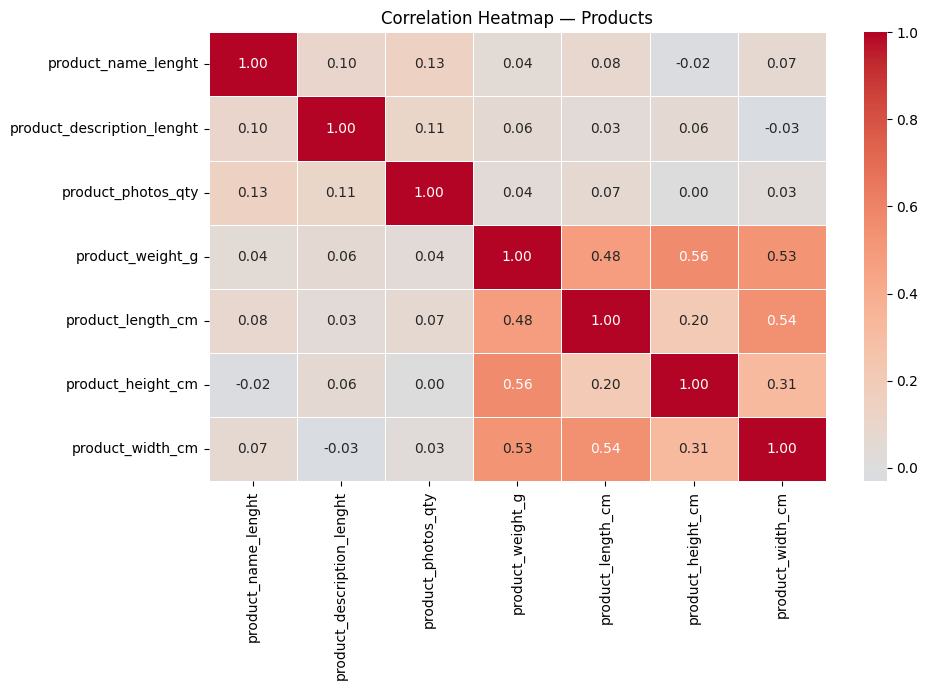

In [53]:
plot_correlation_heatmap(products, 'Products')

Payments

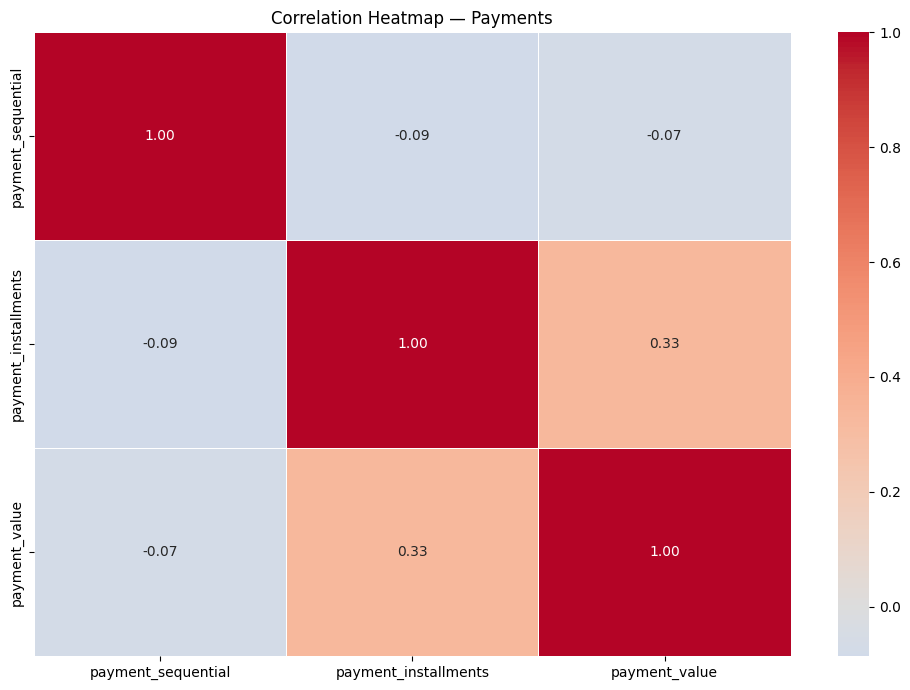

In [54]:
plot_correlation_heatmap(payments, 'Payments')